In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import random

In [2]:
X,y= make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [3]:
df= pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target']=y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.612018,-0.993136,-1.262997,-0.554150,0.519759,1
1,-0.114918,-1.109627,-1.645008,-1.529447,1.132893,1
2,0.642544,-0.275986,-0.938142,0.743265,-0.409803,0
3,0.553365,-3.751167,-0.646145,5.136456,0.500456,0
4,2.494726,-2.351652,2.344564,1.752525,1.935250,0


In [4]:
# function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [5]:
# function for feature sampling
def sample_features(df,percent):
    cols=random.sample(df.columns.tolist()[:-1],int(percent*(df.shape[1]-1)))
    new_df=df[cols]
    new_df['target']=df['target']
    return new_df

In [6]:
# function for combined sampling
def combined_sampling(df, row_percent, col_percent):
    new_df=sample_rows(df,row_percent)
    return sample_features(new_df,col_percent)

In [7]:
df1=combined_sampling(df,0.5,0.5)

In [8]:
df2=combined_sampling(df,0.5,0.5)

In [9]:
df3=combined_sampling(df,0.5,0.5)

In [10]:
print(df1.columns)
print(df2.columns)
print(df3.columns)

Index(['col3', 'col2', 'target'], dtype='str')
Index(['col1', 'col5', 'target'], dtype='str')
Index(['col2', 'col4', 'target'], dtype='str')


In [11]:
df1

,col3,col2,target
19,-2.753516,0.647519,1
14,-0.820757,-1.414326,1
1,-1.645008,-1.109627,1
10,-1.550525,-0.756997,1
14,-0.820757,-1.414326,1
10,-1.550525,-0.756997,1
77,0.083325,-2.774182,1
34,-1.078566,-0.724097,1
90,-1.014905,-0.999816,1
19,-2.753516,0.647519,1


In [12]:
from sklearn.tree import DecisionTreeClassifier
clf1=DecisionTreeClassifier()
clf2=DecisionTreeClassifier()
clf3=DecisionTreeClassifier()

In [13]:
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df2.iloc[:,0:2],df2.iloc[:,-1])
clf3.fit(df3.iloc[:,0:2],df3.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [14]:
from sklearn.tree import plot_tree 

[Text(0.5769230769230769, 0.9375, 'x[0] <= 0.357\ngini = 0.471\nsamples = 50\nvalue = [19, 31]'),
 Text(0.3076923076923077, 0.8125, 'x[1] <= -1.852\ngini = 0.307\nsamples = 37\nvalue = [7, 30]'),
 Text(0.4423076923076923, 0.875, 'True  '),
 Text(0.15384615384615385, 0.6875, 'x[0] <= -0.495\ngini = 0.5\nsamples = 6\nvalue = [3, 3]'),
 Text(0.07692307692307693, 0.5625, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.23076923076923078, 0.5625, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.46153846153846156, 0.6875, 'x[1] <= -0.584\ngini = 0.225\nsamples = 31\nvalue = [4, 27]'),
 Text(0.38461538461538464, 0.5625, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.5384615384615384, 0.5625, 'x[0] <= -0.808\ngini = 0.444\nsamples = 12\nvalue = [4, 8]'),
 Text(0.46153846153846156, 0.4375, 'x[0] <= -3.008\ngini = 0.32\nsamples = 10\nvalue = [2, 8]'),
 Text(0.38461538461538464, 0.3125, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.5384615384615384, 0.3125, 'x[0] <= -1.08\ngini

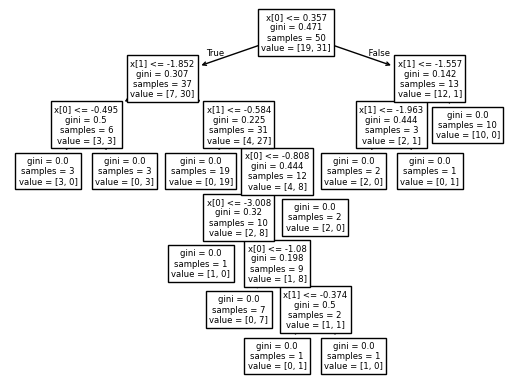

In [15]:
plot_tree(clf1)

[Text(0.2, 0.9444444444444444, 'x[0] <= -0.714\ngini = 0.487\nsamples = 50\nvalue = [21.0, 29.0]'),
 Text(0.1, 0.8333333333333334, 'gini = 0.0\nsamples = 20\nvalue = [0, 20]'),
 Text(0.15000000000000002, 0.8888888888888888, 'True  '),
 Text(0.3, 0.8333333333333334, 'x[1] <= -0.802\ngini = 0.42\nsamples = 30\nvalue = [21, 9]'),
 Text(0.25, 0.8888888888888888, '  False'),
 Text(0.2, 0.7222222222222222, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4, 0.7222222222222222, 'x[0] <= 1.851\ngini = 0.346\nsamples = 27\nvalue = [21, 6]'),
 Text(0.3, 0.6111111111111112, 'x[1] <= -0.064\ngini = 0.42\nsamples = 20\nvalue = [14, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 5\nvalue = [5, 0]'),
 Text(0.4, 0.5, 'x[1] <= 0.52\ngini = 0.48\nsamples = 15\nvalue = [9, 6]'),
 Text(0.3, 0.3888888888888889, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.5, 0.3888888888888889, 'x[0] <= 1.089\ngini = 0.375\nsamples = 12\nvalue = [9, 3]'),
 Text(0.3, 0.2777777777777778, 'x[0] <= -0.208\ngini = 0.198

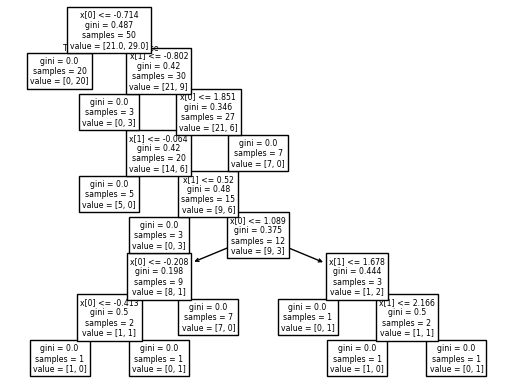

In [16]:
plot_tree(clf2)


[Text(0.2857142857142857, 0.9166666666666666, 'x[1] <= -0.427\ngini = 0.499\nsamples = 50\nvalue = [26, 24]'),
 Text(0.14285714285714285, 0.75, 'gini = 0.0\nsamples = 19\nvalue = [0, 19]'),
 Text(0.21428571428571427, 0.8333333333333333, 'True  '),
 Text(0.42857142857142855, 0.75, 'x[0] <= -0.828\ngini = 0.271\nsamples = 31\nvalue = [26, 5]'),
 Text(0.3571428571428571, 0.8333333333333333, '  False'),
 Text(0.2857142857142857, 0.5833333333333334, 'gini = 0.0\nsamples = 20\nvalue = [20, 0]'),
 Text(0.5714285714285714, 0.5833333333333334, 'x[0] <= -0.754\ngini = 0.496\nsamples = 11\nvalue = [6, 5]'),
 Text(0.42857142857142855, 0.4166666666666667, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.7142857142857143, 0.4166666666666667, 'x[0] <= 0.225\ngini = 0.375\nsamples = 8\nvalue = [6, 2]'),
 Text(0.5714285714285714, 0.25, 'x[1] <= 0.698\ngini = 0.48\nsamples = 5\nvalue = [3, 2]'),
 Text(0.42857142857142855, 0.08333333333333333, 'gini = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.714285

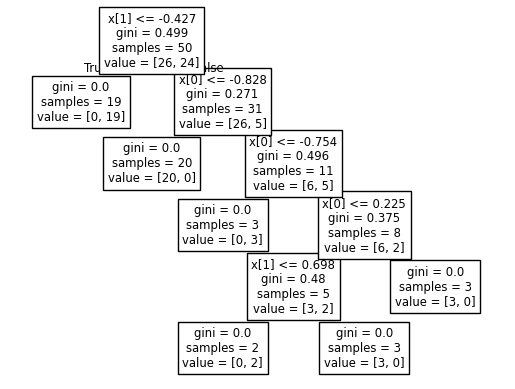

In [17]:
plot_tree(clf3)


In [21]:
clf1.predict(np.array([-2.753516,0.647519]).reshape(1,2))

C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [22]:
clf2.predict(np.array([-2.753516,0.647519]).reshape(1,2))


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

In [23]:
clf3.predict(np.array([-2.753516,0.647519]).reshape(1,2))


C:\Users\DELL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0])